In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# INITIAL CONDITIONS
x=10
v=0

# PARAMETERS
k=1
dt=0.001
m=5
t=1000
sigma=50
gamma=0.1
NS=10

In [ ]:
tl=[]
xle=[]
vle=[]
Ecle=[]
Eple=[]
Etle=[]

xe=x
ve=v

A=int(t/dt)

for h in range(A):
    dW=np.random.normal(0,1)*np.sqrt(dt)
    t=h*dt
    tl.append(t)
    
    xle.append(xe)
    vle.append(ve)

    Ece=m*ve**2/2
    Epe=k*xe**2/2
    Ete=Ece+Epe
    
    Ecle.append(Ece)
    Eple.append(Epe)
    Etle.append(Ete)

    xe_new = xe + ve*dt
    ve_new = ve - k*xe*dt/m + sigma/m*dW - gamma/m*ve*dt


    xe = xe_new
    ve = ve_new

Etm=np.mean(Etle)
vem=np.mean(vle)
xem=np.mean(xle)
xvar=np.var(xle)
vvar=np.var(vle)
        

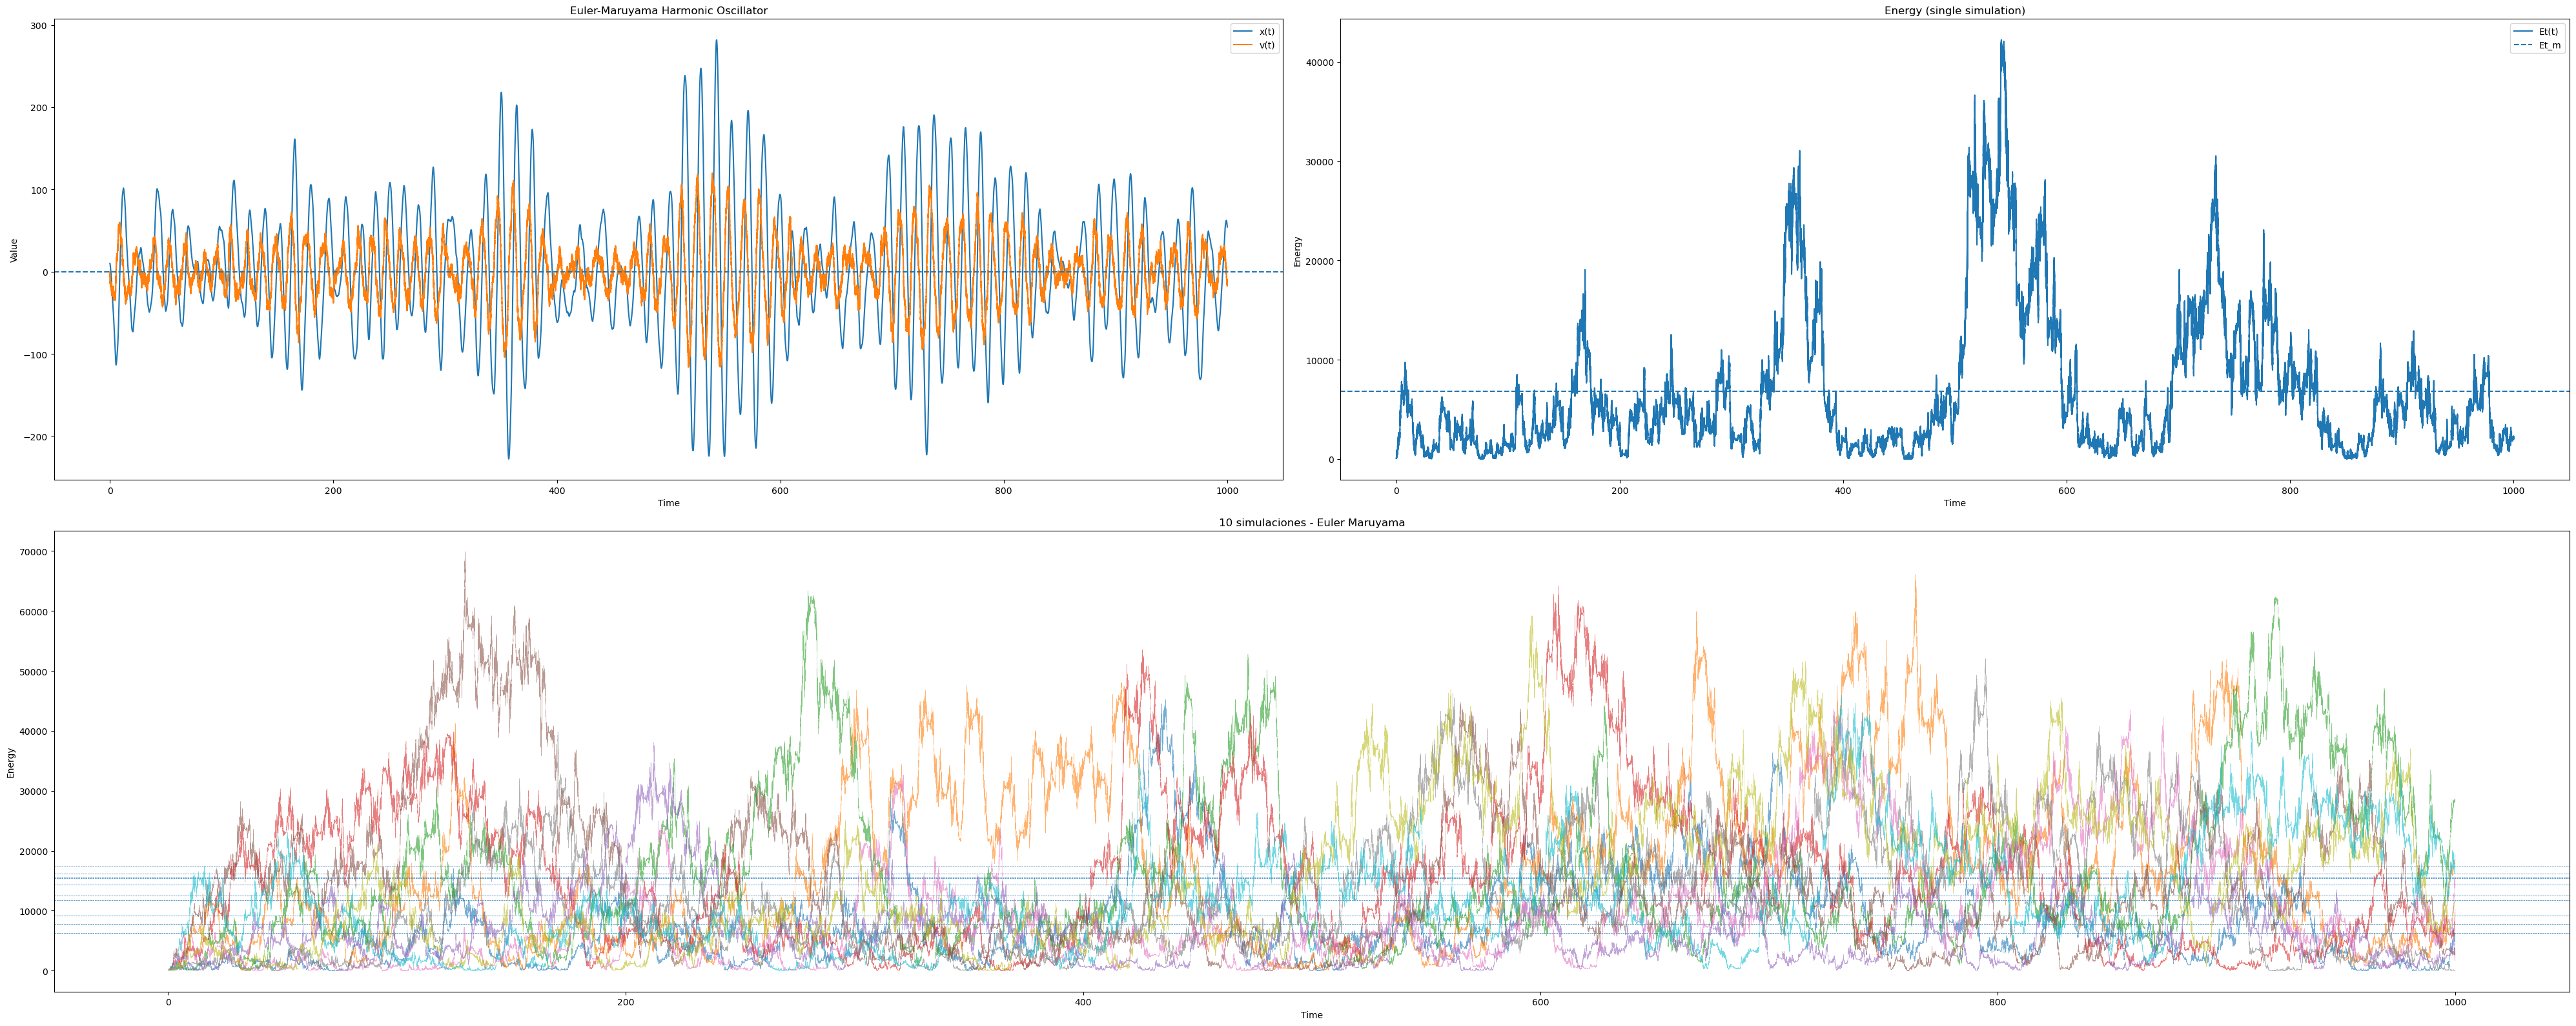

mean_x = 0.37207738878967794 	 mean v_= 0.04419343897065324
var_x = 6741.643287022173 	 var v_= 1379.6885599878503


In [ ]:
fig = plt.figure(figsize=(40,16))
gs = fig.add_gridspec(2, 2)

# --- (0,0) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(tl, xle, label="x(t)")
ax1.plot(tl, vle, label="v(t)")
ax1.axhline(0, linestyle='--')
ax1.set_title("Euler-Maruyama Harmonic Oscillator")
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.legend()

# --- (0,1) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tl, Etle, label="Et(t)")
ax2.axhline(Etm, linestyle='--', label='Et_m')
ax2.set_title("Energy (single simulation)")
ax2.set_xlabel("Time")
ax2.set_ylabel("Energy")
ax2.legend()

# --- (1,0) y (1,1) juntos ---
ax3 = fig.add_subplot(gs[1, :])

t_total = t
A = int(t_total/dt)

for i in range(NS):

    xe = x
    ve = v
    
    tl_i = [] 
    Etle_i = []

    for h in range(A):
        dW = np.random.normal(0,1)*np.sqrt(dt)
        t_actual = h*dt
        
        tl_i.append(t_actual)

        Ece = m*ve**2/2
        Epe = k*xe**2/2
        Ete = Ece + Epe
        Etle_i.append(Ete)

        xe_new = xe + ve*dt
        ve_new = ve - k*xe*dt/m - gamma/m*ve*dt + sigma/m*dW

        xe = xe_new
        ve = ve_new
    
    Etm_i = np.mean(Etle_i)

    min_len = min(len(tl_i), len(Etle_i))

    ax3.axhline(Etm_i, linestyle='--', lw=0.5)
    ax3.plot(tl_i[:min_len], Etle_i[:min_len], lw=0.3, alpha=0.6)

ax3.set_xlabel("Time")
ax3.set_ylabel("Energy")
ax3.set_title(f"{NS} simulaciones - Euler Maruyama")

plt.tight_layout()
plt.show()

print('mean_x =',xem, '\t', 'mean v_=',vem)
print('var_x =',xvar, '\t', 'var v_=',vvar)